In [3]:
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

import torch
from torch.utils.data import DataLoader, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor

from diffusion_lib import (
    VEProcess, VPProcess,
    LinearSchedule, CosineSchedule,
    EulerMaruyamaSampler,
    GenerativeDiffusionModel,
    CosineSchedule,
    ExponentialSchedule
)
from diffusion_lib import UNetScoreModelColor as ScoreNetColor


DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
N_IMAGES = 500  
N_STEPS_VE  = 500    # VE (Brownian)
N_STEPS_VP  = 1500   # VP-* (Linear / Cosine / Exponential)
IMG_SHAPE = (3, 32, 32)
SEED      = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
print(f'Device: {DEVICE}')

Device: mps


## 1 · Real images — SVHN train split

Only `train_32x32.mat` is available locally. We sample **N_IMAGES** images as a tensor `[N, 3, 32, 32]` in `[0, 1]`.

In [4]:
data_train = datasets.SVHN(
    root='data_copy',
    split='train',
    download=False,
    transform=ToTensor(),
)

subset_idx  = np.random.choice(len(data_train), size=N_IMAGES, replace=False)
data_subset = Subset(data_train, subset_idx)

real_images = torch.stack([data_subset[i][0] for i in range(len(data_subset))])
print(f'Real images: {real_images.shape}  min={real_images.min():.3f}  max={real_images.max():.3f}')

Real images: torch.Size([500, 3, 32, 32])  min=0.000  max=1.000


## 2 · VE (Brownian) model

Variance-Exploding process with $\sigma=25$. Forward SDE: $dx = \sigma^t\,dW$.

In [5]:
ve_process     = VEProcess(sigma=25.0)
score_model_ve = ScoreNetColor(marginal_prob_std=ve_process.sigma_t).to(DEVICE)

ckpt_ve = torch.load(
    'color_digits_checkpoints/color_digits_VE-Brownian.pth',
    map_location=DEVICE,
    weights_only=True,
)
score_model_ve.load_state_dict(ckpt_ve)
score_model_ve.eval()

gm_ve = GenerativeDiffusionModel(ve_process, EulerMaruyamaSampler(), score_model_ve, DEVICE)
print('VE model loaded')

VE model loaded


## 3 · VP (Linear schedule) model

Variance-Preserving process with linear schedule $\beta(t)=\beta_{\min}+(\beta_{\max}-\beta_{\min})t$.

In [6]:
vp_process     = VPProcess(schedule=LinearSchedule())
score_model_vp = ScoreNetColor(marginal_prob_std=vp_process.sigma_t).to(DEVICE)

ckpt_vp = torch.load(
    'color_digits_checkpoints/color_digits_VP-Linear.pth',
    map_location=DEVICE,
    weights_only=True,
)
score_model_vp.load_state_dict(ckpt_vp)
score_model_vp.eval()

gm_vp = GenerativeDiffusionModel(vp_process, EulerMaruyamaSampler(), score_model_vp, DEVICE)
print('VP-Linear model loaded')

VP-Linear model loaded


In [7]:
vp_process_cos     = VPProcess(schedule=CosineSchedule())
score_model_vp_cos = ScoreNetColor(marginal_prob_std=vp_process_cos.sigma_t).to(DEVICE)


ckpt_vp_cos = torch.load(
    'color_digits_checkpoints/color_digits_VP-Cosine.pth',
    map_location=DEVICE,
    weights_only=True,
)
score_model_vp_cos.load_state_dict(ckpt_vp_cos)
score_model_vp_cos.eval()

gm_vp_cos = GenerativeDiffusionModel(vp_process_cos, EulerMaruyamaSampler(), score_model_vp_cos, DEVICE)
gm_vp_cos.T = 0.999
print('VP-Cosine model loaded')

VP-Cosine model loaded


In [8]:
vp_process_exp     = VPProcess(schedule=ExponentialSchedule())
score_model_vp_exp = ScoreNetColor(marginal_prob_std=vp_process_exp.sigma_t).to(DEVICE)

ckpt_vp_exp = torch.load(
    'color_digits_checkpoints/color_digits_VP-Exponential.pth',
    map_location=DEVICE,
    weights_only=True,
)
score_model_vp_exp.load_state_dict(ckpt_vp_exp)
score_model_vp_exp.eval()

gm_vp_exp = GenerativeDiffusionModel(vp_process_exp, EulerMaruyamaSampler(), score_model_vp_exp, DEVICE)
print('VP-Exponential model loaded')

VP-Exponential model loaded


## 4 · Generate synthetic samples

`return_trajectory=False` returns only the final images `[N, 3, 32, 32]`.

In [9]:
print(f'Generating {N_IMAGES} images with VE model ...')
with torch.no_grad():
    fake_ve = gm_ve.sample(n_images=N_IMAGES, img_shape=IMG_SHAPE, n_steps=N_STEPS_VE)
fake_ve = fake_ve.clamp(0.0, 1.0).cpu()
print(f'  VE  samples: {fake_ve.shape}')

print(f'Generating {N_IMAGES} images with VP-Linear model ...')
with torch.no_grad():
    fake_vp = gm_vp.sample(n_images=N_IMAGES, img_shape=IMG_SHAPE, n_steps=N_STEPS_VP)
fake_vp = fake_vp.clamp(0.0, 1.0).cpu()
print(f'  VP  samples: {fake_vp.shape}')

print(f'Generating {N_IMAGES} images with VP-Cosine model ...')
with torch.no_grad():
    fake_vp_cos = gm_vp_cos.sample(n_images=N_IMAGES, img_shape=IMG_SHAPE, n_steps=N_STEPS_VP)
fake_vp_cos = fake_vp_cos.clamp(0.0, 1.0).cpu()
print(f'  VP-Cosine samples: {fake_vp_cos.shape}')  

print(f'Generating {N_IMAGES} images with VP-Exponential model ...')
with torch.no_grad():
    fake_vp_exp = gm_vp_exp.sample(n_images=N_IMAGES, img_shape=IMG_SHAPE, n_steps=N_STEPS_VP)
fake_vp_exp = fake_vp_exp.clamp(0.0, 1.0).cpu()
print(f'  VP-Exponential samples: {fake_vp_exp.shape}')

Generating 500 images with VE model ...
  VE  samples: torch.Size([500, 3, 32, 32])
Generating 500 images with VP-Linear model ...
  VP  samples: torch.Size([500, 3, 32, 32])
Generating 500 images with VP-Cosine model ...
  VP-Cosine samples: torch.Size([500, 3, 32, 32])
Generating 500 images with VP-Exponential model ...
  VP-Exponential samples: torch.Size([500, 3, 32, 32])


## 5 · FID computation

$$\text{FID} = \|\mu_r - \mu_f\|^2 + \operatorname{Tr}\!\left(\Sigma_r + \Sigma_f - 2\left(\Sigma_r\Sigma_f\right)^{1/2}\right)$$

Features from InceptionV3 `pool_3` (2048-dim), images resized to $299\times299$. **Lower FID = better.**

In [10]:
from diffusion_lib.metrics.fid_is import compute_fid

fid_ve = compute_fid(real_images, fake_ve, device=DEVICE)
print(f'FID  VE  (Brownian) : {fid_ve:.2f}')

fid_vp = compute_fid(real_images, fake_vp, device=DEVICE)
print(f'FID  VP  (Linear)   : {fid_vp:.2f}')

fid_vp_exp = compute_fid(real_images, fake_vp_exp, device=DEVICE)
print(f'FID  VP  (Exponential)   : {fid_vp_exp:.2f}')

fid_vp_cos = compute_fid(real_images, fake_vp_cos, device=DEVICE)
print(f'FID  VP  (Cosine)   : {fid_vp_cos:.2f}')    





FID  VE  (Brownian) : 248.89
FID  VP  (Linear)   : 215.81
FID  VP  (Exponential)   : 192.50
FID  VP  (Cosine)   : 191.22


## 6 · Visual comparison

8 real images, 8 generated by each model.

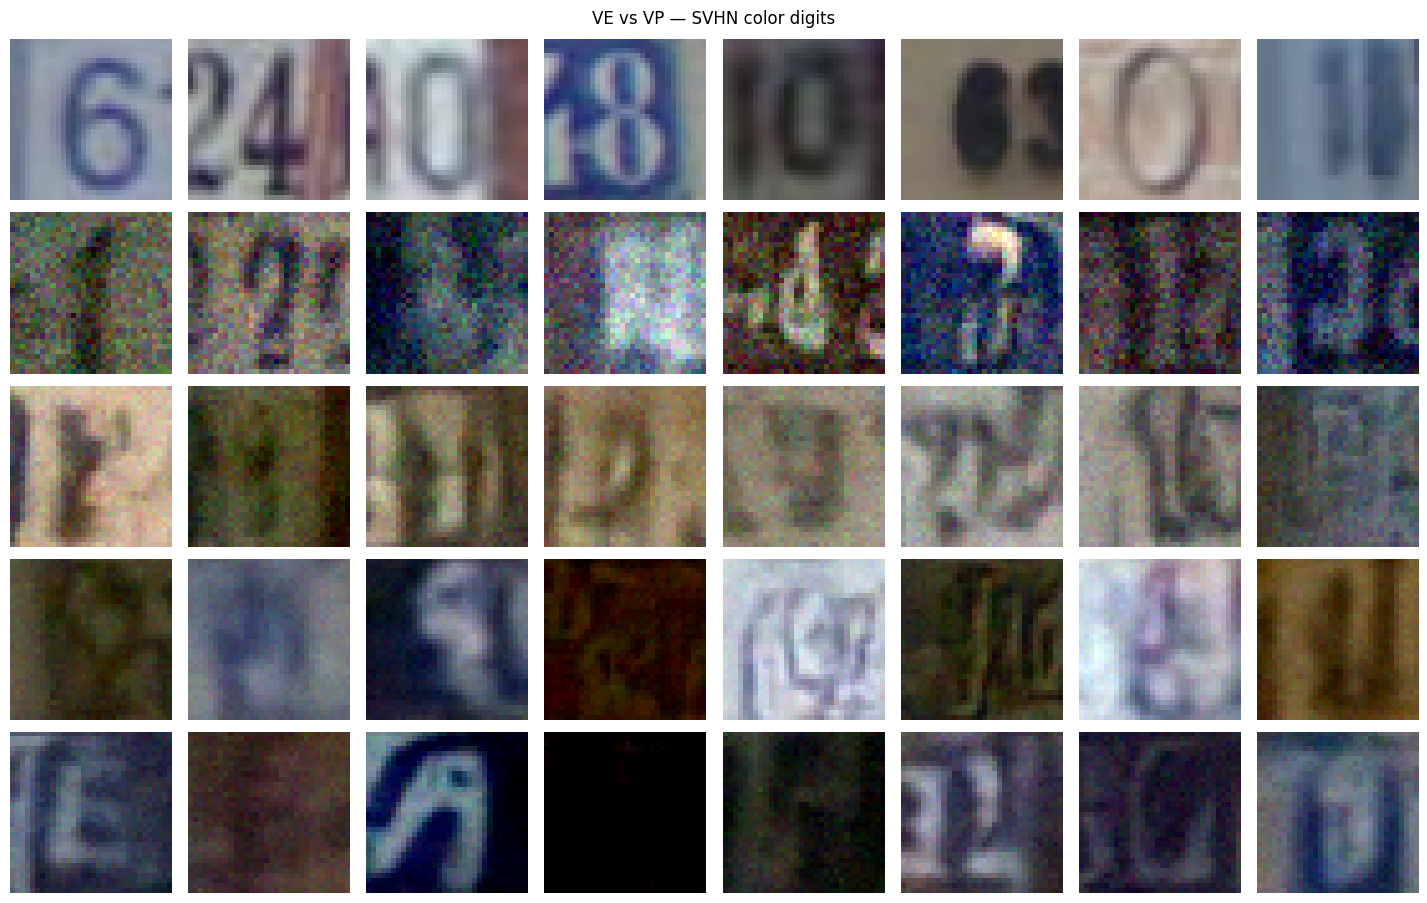

Saved Figuras/fid_ve_vp_comparison.png


In [11]:
N_SHOW = 8
fig, axes = plt.subplots(5, N_SHOW, figsize=(N_SHOW * 1.8, 5.5 * 5 / 3))

row_data = [
    ('Real SVHN',                             real_images),
    (f'VE  Brownian      FID={fid_ve:.1f}',   fake_ve),
    (f'VP  Linear        FID={fid_vp:.1f}',   fake_vp),
    (f'VP  Cosine        FID={fid_vp_cos:.1f}', fake_vp_cos),
    (f'VP  Exponential   FID={fid_vp_exp:.1f}', fake_vp_exp),
]

for row, (label, batch) in enumerate(row_data):
    for col in range(N_SHOW):
        img = batch[col].permute(1, 2, 0).numpy()
        axes[row, col].imshow(np.clip(img, 0.0, 1.0))
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=0, labelpad=100, va='center')

plt.suptitle('VE vs VP — SVHN color digits', fontsize=12)
plt.tight_layout()
import pathlib; pathlib.Path('Figuras').mkdir(exist_ok=True)
plt.savefig('Figuras/fid_ve_vp_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved Figuras/fid_ve_vp_comparison.png')



## 7 · Summary table

In [12]:
import pandas as pd

df = pd.DataFrame({
    'Model'   : ['VE (Brownian)', 'VP (Linear)', 'VP (Cosine)', 'VP (Exponential)'],
    'Process' : ['Variance Exploding'] + ['Variance Preserving'] * 3,
    'Schedule': ['-', 'Linear', 'Cosine', 'Exponential'],
    'Sampler' : ['Euler-Maruyama'] * 4,
    'N steps' : [N_STEPS_VE, N_STEPS_VP, N_STEPS_VP, N_STEPS_VP],
    'N images': [N_IMAGES] * 4,
    'FID'     : [round(fid_ve, 2), round(fid_vp, 2), round(fid_vp_cos, 2), round(fid_vp_exp, 2)],
})
df.set_index('Model', inplace=True)
print(df.to_string())

                              Process     Schedule         Sampler  N steps  N images     FID
Model                                                                                        
VE (Brownian)      Variance Exploding            -  Euler-Maruyama      200       500  248.89
VP (Linear)       Variance Preserving       Linear  Euler-Maruyama      200       500  215.81
VP (Cosine)       Variance Preserving       Cosine  Euler-Maruyama      200       500  191.22
VP (Exponential)  Variance Preserving  Exponential  Euler-Maruyama      200       500  192.50
